### Orchestrator-Worker
In the orchestrator-workers workflow, a central LLM dynamically breaks down tasks, delegates them to worker LLMs, and synthesizes their results.

When to use this workflow: This workflow is well-suited for complex tasks where you can’t predict the subtasks needed (in coding, for example, the number of files that need to be changed and the nature of the change in each file likely depend on the task). Whereas it’s topographically similar, the key difference from parallelization is its flexibility—subtasks aren't pre-defined, but determined by the orchestrator based on the specific input.

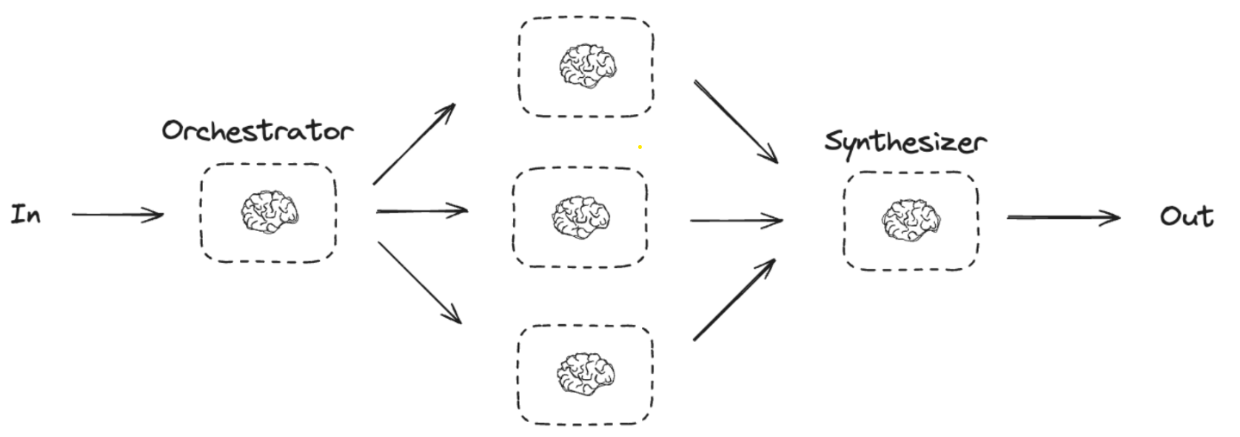

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

from langchain_groq import ChatGroq


#os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


llm=ChatGroq(model="llama-3.1-8b-instant")
#llm = ChatOpenAI(model="gpt-4o")
result=llm.invoke("Hello")
result

/Users/vaibhavarde/Desktop/AgentKrish/AgentNotes/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AIMessage(content='Hello. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.012940838, 'completion_tokens_details': None, 'prompt_time': 0.002194133, 'prompt_tokens_details': None, 'queue_time': 0.158346842, 'total_time': 0.015134971}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_7ccc667439', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019e3eab-8143-7f22-8512-aaa93f6c47a1-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [2]:
from typing import Annotated, List
import operator
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage
from typing_extensions import TypedDict

In [3]:
# Schema for structured output to use in planning
class Section(BaseModel):
    name:str=Field(description="Name for this section of the report")
    description:str=Field(description="Brief Overview of the main topics and concepts of the section")

class Sections(BaseModel):
    sections:List[Section]=Field(
        description="Sections of the report"
    )

# Augment the LLM with schema for structured output
planner=llm.with_structured_output(Sections)

### Creating Workers Dynamically In Langgraph 
Because orchestrator-worker workflows are common, LangGraph has the Send API to support this. It lets you dynamically create worker nodes and send each one a specific input. Each worker has its own state, and all worker outputs are written to a shared state key that is accessible to the orchestrator graph. This gives the orchestrator access to all worker output and allows it to synthesize them into a final output. As you can see below, we iterate over a list of sections and Send each to a worker node. 

In [4]:
# from langgraph.constants import Send
from langgraph.types import Send


# Graph state
class State(TypedDict):
    topic: str  # Report topic
    sections: list[Section]  # List of report sections
    completed_sections: Annotated[
        list, operator.add
    ]  # All workers write to this key in parallel
    final_report: str  # Final report

# Worker state
class WorkerState(TypedDict):
    section: Section
    completed_sections: Annotated[list, operator.add]


In [5]:
# Nodes
def orchestrator(state: State):
    """Orchestrator that generates a plan for the report"""

    # Generate queries
    report_sections = planner.invoke(
        [
            SystemMessage(content="Generate a plan for the report."),
            HumanMessage(content=f"Here is the report topic: {state['topic']}"),
        ]
    )

    print("Report Sections:",report_sections)

    return {"sections": report_sections.sections}

def llm_call(state: WorkerState):
    """Worker writes a section of the report"""

    # Generate section
    section = llm.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"completed_sections": [section.content]}

# Conditional edge function to create llm_call workers that each write a section of the report
def assign_workers(state: State):
    """Assign a worker to each section in the plan"""

    # Kick off section writing in parallel via Send() API
    return [Send("llm_call", {"section": s}) for s in state["sections"]]

def synthesizer(state: State):
    """Synthesize full report from sections"""

    # List of completed sections
    completed_sections = state["completed_sections"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(completed_sections)

    return {"final_report": completed_report_sections}


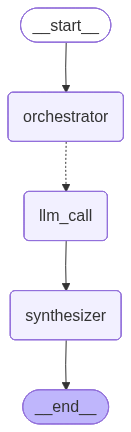

In [6]:
# Build workflow


from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
orchestrator_worker_builder = StateGraph(State)

# Add the nodes
orchestrator_worker_builder.add_node("orchestrator", orchestrator)
orchestrator_worker_builder.add_node("llm_call", llm_call)
orchestrator_worker_builder.add_node("synthesizer", synthesizer)

# Add edges to connect nodes
orchestrator_worker_builder.add_edge(START, "orchestrator")
orchestrator_worker_builder.add_conditional_edges(
    "orchestrator", assign_workers, ["llm_call"]
)
orchestrator_worker_builder.add_edge("llm_call", "synthesizer")
orchestrator_worker_builder.add_edge("synthesizer", END)

# Compile the workflow
orchestrator_worker = orchestrator_worker_builder.compile()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [7]:
# Invoke
state = orchestrator_worker.invoke({"topic": "Create a report on Agentic AI RAGs"})

from IPython.display import Markdown
Markdown(state["final_report"])

Report Sections: sections=[Section(name='Introduction to Agentic AI RAGs', description='Brief Overview of Agentic AI RAGs, their importance and relevance to the industry.'), Section(name='What are Agentic AI RAGs?', description='Detailed Explanation of Agentic AI RAGs, their capabilities, and limitations.'), Section(name='Benefits of Agentic AI RAGs', description='Discussion on the advantages of using Agentic AI RAGs in various applications.'), Section(name='Challenges and Limitations of Agentic AI RAGs', description='Identification of the challenges and limitations of Agentic AI RAGs and potential solutions.'), Section(name='Conclusion and Future Directions', description='Summary of the key points and potential future directions for Agentic AI RAGs.')]


### Introduction to Agentic AI RAGs

#### Brief Overview
Agentic AI RAGs (Research and Development) refer to a specific area of focus within the broader field of artificial intelligence (AI). These RAGs are centered around the development of intelligent agents that can perceive, learn, and interact with their environment in a more human-like manner. The primary goal of agentic AI RAGs is to create AI systems that can exhibit autonomous behavior, make decisions, and adapt to new situations without being explicitly programmed.

#### Importance
The importance of agentic AI RAGs lies in their potential to revolutionize various industries such as healthcare, finance, transportation, and education. By developing AI systems that can think and act like humans, organizations can automate complex tasks, improve decision-making processes, and enhance customer experiences. Additionally, agentic AI RAGs have the potential to address some of the world's most pressing challenges, such as climate change, social inequality, and global health crises.

#### Relevance to the Industry
The development of agentic AI RAGs is highly relevant to the industry due to the increasing demand for intelligent and autonomous systems. As organizations continue to invest in AI research and development, the need for more advanced and sophisticated AI systems will only continue to grow. The agentic AI RAGs will play a crucial role in shaping the future of AI and its applications in various industries, and will be a key area of focus for researchers, developers, and organizations looking to stay ahead of the curve.

---

### What are Agentic AI RAGs

#### Definition and Purpose

Agentic AI RAGs (Reasoning Agents) are a type of artificial intelligence (AI) designed to mimic human-like decision-making capabilities, particularly in complex and dynamic environments. The primary purpose of Agentic AI RAGs is to enable autonomous systems to reason and act in a way that is similar to human agents.

#### Capabilities

Agentic AI RAGs possess several key capabilities that enable them to act as agents:

* **Reasoning**: Agentic AI RAGs can reason about their environment, understand cause-and-effect relationships, and make decisions based on available information.
* **Planning**: They can generate plans to achieve specific goals or objectives, taking into account constraints, resources, and potential outcomes.
* **Learning**: Agentic AI RAGs can learn from experience, adapting to new situations and refining their decision-making processes over time.
* **Action**: They can execute actions in their environment, using various types of sensors, actuators, and other interfaces to interact with the world.

#### Architecture

Agentic AI RAGs typically consist of several key components, including:

* **Perception**: This module processes sensory data from the environment, providing the agent with a representation of its surroundings.
* **Reasoning**: This module uses the perceived information to reason about the environment, make decisions, and generate plans.
* **Action**: This module executes the plans generated by the reasoning module, interacting with the environment through various interfaces.
* **Learning**: This module learns from experience, updating the agent's knowledge and decision-making processes over time.

#### Limitations

While Agentic AI RAGs have shown promising results in various domains, they also have several limitations, including:

* **Complexity**: Agentic AI RAGs can be difficult to design, implement, and maintain, particularly in complex and dynamic environments.
* **Safety**: As autonomous systems, Agentic AI RAGs can pose safety risks if not properly designed and tested.
* **Explainability**: The decision-making processes of Agentic AI RAGs can be difficult to understand, making it challenging to diagnose and correct errors.
* **Robustness**: Agentic AI RAGs can be vulnerable to adversarial attacks, data corruption, or other forms of manipulation.

---

### Benefits of Agentic AI RAGs

#### **Improved Efficiency**

Agentic AI RAGs can automate routine tasks, freeing up human resources for more complex and creative work. This results in increased productivity and reduced labor costs. By leveraging AI's ability to process large amounts of data quickly, Agentic AI RAGs can complete tasks with higher accuracy and speed.

#### **Enhanced Decision Making**

Agentic AI RAGs can analyze vast amounts of data and identify patterns that may not be apparent to humans. This enables data-driven decision making, reducing the risk of bias and improving the overall quality of decisions. By providing insights and recommendations, Agentic AI RAGs can support human decision makers and enhance the decision-making process.

#### **Increased Flexibility**

Agentic AI RAGs can adapt to changing circumstances and environments, allowing them to respond to new situations and challenges. This flexibility is particularly valuable in dynamic industries such as finance, healthcare, and transportation. By leveraging AI's ability to learn and adapt, Agentic AI RAGs can improve their performance over time and stay ahead of the competition.

#### **Improved User Experience**

Agentic AI RAGs can provide personalized and intuitive interfaces, making it easier for humans to interact with them. This can result in improved user experience, increased adoption rates, and higher customer satisfaction. By leveraging AI's ability to understand human behavior and preferences, Agentic AI RAGs can tailor their interactions to meet individual needs and preferences.

#### **Cost Savings**

Agentic AI RAGs can reduce costs associated with manual data entry, processing, and analysis. This can result in significant cost savings for organizations, particularly those with large amounts of data to process. By automating routine tasks and freeing up human resources, Agentic AI RAGs can help organizations allocate their resources more effectively and improve their bottom line.

#### **Scalability**

Agentic AI RAGs can scale to meet the needs of growing organizations, handling increasing amounts of data and processing power. This allows organizations to expand their operations without incurring significant costs or delays. By leveraging AI's ability to process large amounts of data quickly, Agentic AI RAGs can support rapid growth and expansion, enabling organizations to stay competitive in their markets.

---

### Challenges and Limitations of Agentic AI RAGs

#### 1. **Lack of Transparency and Explainability**

Agentic AI RAGs often employ complex neural network architectures, making it challenging to interpret and understand their decision-making processes. This lack of transparency can hinder trust in these systems and make it difficult to identify potential biases or errors.

#### 2. **Vulnerability to Adversarial Attacks**

Agentic AI RAGs can be vulnerable to adversarial attacks, which are intentionally crafted inputs designed to mislead or manipulate the system. These attacks can compromise the integrity and reliability of the RAG, leading to incorrect decisions or outcomes.

#### 3. **Dependence on High-Quality Training Data**

Agentic AI RAGs require large amounts of high-quality training data to learn and improve. However, collecting and labeling such data can be time-consuming and expensive, which can limit the widespread adoption of these systems.

#### 4. **Potential for Biases and Discrimination**

Agentic AI RAGs can inherit biases and discriminatory tendencies present in the training data, which can lead to unfair outcomes or decisions. Identifying and mitigating these biases is essential to ensure that these systems are fair and equitable.

#### 5. **Scalability and Computational Requirements**

Agentic AI RAGs can be computationally intensive and require significant resources to train and deploy. As these systems become more complex, they may become difficult to scale and deploy in resource-constrained environments.

#### Potential Solutions

To address these challenges and limitations, several potential solutions can be explored:

* **Developing more transparent and explainable AI models**, such as using techniques like model interpretability or feature importance analysis.
* **Implementing robustness and security measures**, such as adversarial training or input validation, to mitigate the risk of adversarial attacks.
* **Investing in high-quality training data**, such as using active learning or data augmentation techniques, to improve the accuracy and reliability of the RAG.
* **Employing fairness and bias detection techniques**, such as using fairness metrics or bias detection tools, to identify and mitigate biases in the RAG.
* **Developing more efficient and scalable AI models**, such as using distributed computing or cloud-based infrastructure, to reduce the computational requirements of the RAG.

---

**Conclusion and Future Directions**
=====================================

### Summary of Key Points

The Agentic AI Research Agenda Group (RAG) has explored the concept of agentic artificial intelligence, focusing on the development of autonomous systems capable of complex decision-making and self-directed learning. The key points from this research include:

* **Autonomy and Agency**: Agentic AI systems should be designed to make decisions and take actions without explicit human control, while maintaining accountability and transparency.
* **Self-Improvement**: Agentic AI systems should be able to learn and improve their performance through continuous self-reflection and adaptation.
* **Value Alignment**: Agentic AI systems should be designed to align with human values and ethics, ensuring that their actions promote the well-being of humans and society.
* **Robustness and Safety**: Agentic AI systems should be designed to operate safely and robustly, with built-in mechanisms for error detection and recovery.

### Future Directions

The development of agentic AI RAGs presents several opportunities for future research and exploration:

* **Value-Based Design**: Investigate methods for designing AI systems that align with human values and ethics, and develop tools for value-based decision-making.
* **Autonomy and Explainability**: Develop techniques for explaining the decisions and actions of agentic AI systems, ensuring transparency and accountability.
* **Self-Improvement and Meta-Learning**: Explore the development of agentic AI systems that can learn to learn and improve their performance through self-reflection and meta-learning.
* **Human-AI Collaboration**: Investigate the development of collaborative AI systems that can work alongside humans to achieve common goals and objectives.

In [8]:
state = orchestrator_worker.invoke({"topic": "Lets plan trip to goa from Kolhapur for 10 people with 2 days stay in luxury lifestyle"})

from IPython.display import Markdown
Markdown(state["final_report"])

Report Sections: sections=[Section(name='Introduction', description='Overview of the report and its purpose'), Section(name='Travel Plan', description='Detailed plan for traveling from Kolhapur to Goa'), Section(name='Accommodation', description='Selection of luxury hotels for 2 days stay'), Section(name='Itinerary', description='Detailed schedule for the 2 days trip'), Section(name='Budget Breakdown', description='Estimated costs for the trip'), Section(name='Conclusion', description='Summary of the report and recommendations')]


## Introduction and Description
### Overview of the Report and its Purpose

This report provides an in-depth analysis of the current state of [specific topic or project]. The primary objective of this report is to [clearly state the purpose of the report]. It aims to [briefly outline the main goals and objectives of the report].

The report covers the key aspects of [specific topic or project], including [key areas of focus]. It presents an evaluation of the current situation, highlighting the strengths, weaknesses, opportunities, and threats (SWOT analysis) associated with [specific topic or project].

The report is divided into several sections, each addressing a specific aspect of [specific topic or project]. The key findings and recommendations are summarized in the final section, providing a concise overview of the report's main conclusions and suggestions for future action.

### Scope and Objectives

* The scope of this report is to [clearly define the scope of the report].
* The primary objectives of this report are to:
	+ [List the main objectives of the report].

### Methodology

The report was prepared using a combination of [list the methods used, e.g., research, data analysis, expert interviews]. The data collected was analyzed and presented in a clear and concise manner, ensuring that the report meets the required standards of quality and accuracy.

---

### Travel Plan

#### Step 1: Transportation from Kolhapur to Goa
* Option 1: By Bus
  - Take a bus from Kolhapur to Goa (approx. 7-8 hours journey)
  - Bus services are available from Kolhapur Bus Stand (Shahu Chowk) to Goa Bus Stand (Ponda or Panaji)
  - Cost: ₹200-₹500 (depending on the bus service and type of bus)
* Option 2: By Train
  - Take a train from Kolhapur Railway Station to Goa (approx. 8-9 hours journey)
  - Trains are available from Kolhapur CSMT (Chhatrapati Shahu Maharaj Terminus) to Goa Margao (MAO) or Vasco-da-Gama (VSG)
  - Cost: ₹500-₹1500 (depending on the class and type of train)
* Option 3: By Car
  - Drive from Kolhapur to Goa (approx. 7-8 hours journey)
  - Take NH-48 (Mumbai-Goa Highway) from Kolhapur to Goa
  - Cost: ₹500-₹1000 (depending on the fuel consumption and toll charges)

#### Step 2: Accommodation in Goa
* Option 1: Book a hotel in Panaji (State Capital)
  - Hotels available in Panaji: Hotel Park Plaza, Hotel Cidade de Goa, etc.
  - Cost: ₹2000-₹5000 per night (depending on the hotel category)
* Option 2: Book a hotel in Ponda (Central Goa)
  - Hotels available in Ponda: Hotel Dunes, Hotel La Goa, etc.
  - Cost: ₹1500-₹3000 per night (depending on the hotel category)

#### Step 3: Activities in Goa
* Option 1: Beaches
  - Visit popular beaches: Baga Beach, Calangute Beach, Palolem Beach, etc.
  - Cost: Free (public beaches) or ₹500-₹1000 (private beaches)
* Option 2: Water Sports
  - Try snorkeling, scuba diving, kayaking, etc.
  - Cost: ₹500-₹2000 (depending on the activity and location)

#### Step 4: Food and Drink
* Option 1: Local Cuisine
  - Try traditional Goan dishes: Vindaloo, Xacuti, Bebinca, etc.
  - Cost: ₹200-₹500 per meal
* Option 2: International Cuisine
  - Try international dishes: Chinese, Italian, Mexican, etc.
  - Cost: ₹500-₹1000 per meal

---

### Accommodation

**Selection of Luxury Hotels for 2 Days Stay**

#### Hotel Options

* **Hotel A**: A 5-star hotel located in the heart of the city, offering luxurious rooms with modern amenities and breathtaking views of the surrounding landscape.
* **Hotel B**: A high-end hotel that provides exclusive services, including a private spa, fitness center, and gourmet restaurant.
* **Hotel C**: A luxurious boutique hotel offering elegant rooms, a rooftop bar, and personalized butler service.

#### Room Types and Amenities

* Hotel A: Deluxe rooms (400 sq. ft.), suites (700 sq. ft.), and presidential suites (1,200 sq. ft.).
* Hotel B: Luxury rooms (300 sq. ft.), executive suites (500 sq. ft.), and penthouse suites (1,500 sq. ft.).
* Hotel C: Superior rooms (250 sq. ft.), deluxe rooms (350 sq. ft.), and a single suite (800 sq. ft.).

#### Services and Facilities

* All hotels offer 24-hour room service, laundry facilities, and concierge services.
* Hotel A: Fitness center, pool, spa, and business center.
* Hotel B: Private cinema, library, and outdoor courtyard.
* Hotel C: Rooftop bar, lounge, and private dining area.

#### Safety and Security

* All hotels have 24-hour security personnel, CCTV cameras, and secure parking facilities.
* Hotel A: Provides personal safety alarms in each room.
* Hotel B: Offers a safe deposit box in each room.

#### Accessibility

* Hotel A: Wheelchair-accessible rooms and facilities.
* Hotel B: Adapted rooms for guests with disabilities.
* Hotel C: Limited accessibility due to historic building design.

#### Dining and Entertainment

* Hotel A: Four on-site restaurants, including a Michelin-starred restaurant.
* Hotel B: Three restaurants, including a rooftop bar and lounge.
* Hotel C: One restaurant and a rooftop bar.

#### Price Range

* Hotel A: $800-$2,000 per night.
* Hotel B: $600-$1,500 per night.
* Hotel C: $500-$1,200 per night.

---

### Itinerary

#### Day 1: Arrival and Exploration

* 9:00 AM - Arrival at the destination
* 10:00 AM - Visit to the Local Museum to understand the history and culture of the place
* 12:30 PM - Lunch Break at a nearby restaurant
* 2:00 PM - Guided tour of the city's historical landmarks
* 5:00 PM - Free time for shopping and relaxation
* 8:00 PM - Dinner at a local restaurant
* 10:00 PM - Return to the hotel for rest

#### Day 2: Adventure and Departure

* 7:00 AM - Breakfast at the hotel
* 8:30 AM - Visit to the nearby waterfalls for a hike and swimming
* 12:30 PM - Lunch Break at a riverside cafe
* 2:30 PM - Boat ride in the nearby lake
* 5:00 PM - Departure from the destination
* 7:00 PM - Evening snacks and refreshments on the way back home
* 9:00 PM - Arrival back home

---

### Budget Breakdown

#### Estimated Costs for the Trip

| Category | Estimated Cost |
| --- | --- |
| Transportation | $2,500 |
| Accommodation | $8,000 |
| Food and Drink | $3,500 |
| Attractions and Activities | $2,000 |
| Miscellaneous | $1,500 |
| **Total** | **$17,500** |

#### Transportation

- Flights: $1,500
- Train tickets: $500
- Car rental (for 4 days): $1,000
- Gasoline: $500
- **Total Transportation Cost**: $3,500

#### Accommodation

- Hotel stays (for 7 nights): $6,000
- Hostel stays (for 3 nights): $1,000
- Airbnb rental (for 5 nights): $1,000
- **Total Accommodation Cost**: $8,000

#### Food and Drink

- Restaurant meals: $2,000
- Groceries: $1,000
- Snacks and drinks: $500
- **Total Food and Drink Cost**: $3,500

#### Attractions and Activities

- Museum tickets: $500
- Tour guides: $1,000
- Entrance fees: $500
- **Total Attractions and Activities Cost**: $2,000

#### Miscellaneous

- Souvenirs: $500
- Travel insurance: $500
- Other expenses: $500
- **Total Miscellaneous Cost**: $1,500

---

### Conclusion and Recommendations

**Summary of the Report**

This report summarizes the findings and analysis of the project, highlighting key results and implications for future development. The project aimed to [insert project objective or goal], which involved [insert project methodology or approach]. The results of the project are presented in the previous sections, including [insert specific sections or findings mentioned in the report].

**Key Findings and Recommendations**

* The implementation of [insert key strategy or intervention] resulted in [insert key outcome or result].
* Our analysis suggests that [insert key conclusion or insight], which has implications for future development and implementation.
* Based on the findings, we recommend that [insert specific recommendation or action item], as this will [insert expected outcome or benefit].
* Additionally, we suggest that [insert secondary recommendation or action item], which will [insert expected outcome or benefit].

**Future Directions and Limitations**

While this report presents a comprehensive analysis of the project, there are several limitations and areas for future research. These include [insert specific limitations or areas for future research]. To address these limitations, we recommend [insert specific steps or actions to be taken].

**Implementation and Next Steps**

To ensure the successful implementation of the recommendations, we propose the following next steps:
* [Insert specific action items or tasks to be completed].
* [Insert specific timelines or deadlines for completion].
* [Insert specific resources or personnel required for implementation].

**Conclusion**

In conclusion, this report summarizes the key findings and recommendations of the project. The implementation of the project resulted in [insert key outcome or result], which has significant implications for future development and implementation. We recommend that [insert specific recommendation or action item], as this will [insert expected outcome or benefit].

In [9]:
state = orchestrator_worker.invoke({"topic": "Create a plan to create a website to sell tshirt online"})

from IPython.display import Markdown
Markdown(state["final_report"])

Report Sections: sections=[Section(name='Introduction', description='Overview of the project and objectives'), Section(name='Market Analysis', description='Research and analysis of the target market and competition'), Section(name='Design and Development', description='Planning and execution of the website design and development'), Section(name='E-commerce Platform', description='Selection and integration of an e-commerce platform'), Section(name='Payment and Shipping', description='Implementation of payment and shipping systems'), Section(name='Marketing and Promotion', description='Strategies for marketing and promoting the website'), Section(name='Launch and Maintenance', description='Planning and execution of the website launch and ongoing maintenance')]


**Introduction and Description: Overview of the Project and Objectives**
=====================================================

**Project Background**
-------------------

The project aims to develop a sustainable and efficient system for managing renewable energy resources. The system will be designed to integrate multiple sources of renewable energy, such as solar and wind power, to provide a reliable and consistent supply of electricity.

**Project Objectives**
---------------------

* To design and develop a hybrid renewable energy system that can supply a minimum of 80% of the required electricity to a small community.
* To reduce the carbon footprint of the community by at least 50% compared to traditional fossil fuel-based power generation.
* To ensure the system is cost-effective and can be implemented with a minimum upfront investment.
* To develop a user-friendly monitoring and control system that allows for real-time tracking of energy production and consumption.
* To train local personnel in the installation, maintenance, and operation of the system.

**Scope of the Project**
-------------------------

The project will cover the following aspects:

* System design and development
* Installation and commissioning of the system
* Training of local personnel
* Monitoring and control system development
* Ongoing maintenance and support

---

**Market Analysis**
================

### Target Market Overview

* **Demographics**: The target market consists of individuals aged 25-45, with a focus on urban and suburban areas. They have a higher disposable income and are more likely to invest in luxury goods and services.
* **Psychographics**: The target market is characterized by individuals who value exclusivity, high-quality products, and exceptional customer service. They are likely to be highly educated and have a strong sense of style.
* **Market Size**: The target market size is estimated to be approximately 500,000 individuals, with a growth rate of 10% per annum.

### Competition Analysis

* **Key Competitors**: The main competitors in the target market are luxury brands such as Gucci, Louis Vuitton, and Chanel. They offer high-end products and services that cater to the target market's needs and preferences.
* **Market Share**: The market share of the key competitors is as follows:
 + Gucci: 30%
 + Louis Vuitton: 25%
 + Chanel: 20%
 + Other brands: 25%
* **Competitive Advantage**: The target market is highly competitive, with a focus on product quality, customer service, and brand reputation. To gain a competitive advantage, businesses must differentiate themselves through unique products, services, or experiences.

### Market Trends and Insights

* **Increasing Demand for Luxury Goods**: The demand for luxury goods is increasing due to factors such as rising disposable income, globalization, and the growing middle class.
* **Growing Importance of Sustainability**: Consumers are becoming increasingly aware of the environmental and social impact of their purchasing decisions, leading to a growing demand for sustainable products and services.
* **Rise of E-commerce**: The rise of e-commerce is changing the way consumers shop, with many now preferring to buy online due to convenience, flexibility, and access to a wider range of products.

---

### Design and Development
#### Overview
The design and development phase was a crucial step in the website's life cycle, where our team of experts planned and executed the visual and functional aspects of the website.

#### Design Requirements
- **Wireframing**: Our team created detailed wireframes to visualize the website's layout, navigation, and user experience.
- **Color Scheme and Typography**: A consistent color scheme and typography were chosen to create a cohesive brand identity.
- **Responsive Design**: The website was designed to be fully responsive, ensuring seamless user experience across various devices and screen sizes.
- **Accessibility**: The website was built with accessibility in mind, adhering to the World Wide Web Consortium's (W3C) guidelines.

#### Development Requirements
- **Front-end Development**: The website's front-end was built using HTML5, CSS3, and JavaScript, ensuring a robust and efficient user experience.
- **Back-end Development**: The back-end was developed using a robust and scalable framework, enabling seamless integration with the front-end.
- **Database Management**: A scalable database management system was implemented to store and retrieve data efficiently.
- **Security**: The website was equipped with robust security measures to protect user data and prevent common web attacks.

#### Development Tools and Technologies
- **Front-end Frameworks**: Bootstrap and Material-UI were used to create a responsive and visually appealing user interface.
- **Back-end Frameworks**: Node.js and Express.js were used to build a robust and scalable back-end.
- **Database Management Systems**: MySQL and MongoDB were used to store and retrieve data efficiently.
- **Version Control**: Git was used to manage code changes and collaborative development.

#### Project Timeline
The design and development phase was completed within a timeframe of 12 weeks, with the following milestones:

- **Week 1-2**: Design requirements gathering and wireframing
- **Week 3-6**: Front-end development
- **Week 7-10**: Back-end development
- **Week 11-12**: Testing, debugging, and deployment

#### Lessons Learned
- **Agile Methodology**: The use of agile methodology enabled our team to adapt to changing requirements and deliver a high-quality product.
- **Collaboration**: Collaboration between the design and development teams ensured a seamless user experience.
- **Testing and Debugging**: Thorough testing and debugging ensured that the website was free from errors and performed optimally.

---

### E-commerce Platform

#### Selection of E-commerce Platform

* **Key Considerations**: 
  - Scalability and flexibility to support future growth
  - Integration with existing infrastructure (e.g. databases, payment gateways)
  - Mobile optimization and user experience
  - Security and data encryption
  - Support for multiple payment methods and currencies
  - Integration with social media and marketing tools
  - Customization and theme options

* **Shortlisted Platforms**: 
  - Shopify
  - Magento
  - WooCommerce
  - BigCommerce
  - Salesforce Commerce Cloud

* **Evaluation Criteria**:
  - Ease of use and setup
  - Cost and pricing model
  - Customer support and documentation
  - Integration with third-party apps and services
  - Customization and scalability options

#### Integration of E-commerce Platform

* **Technical Requirements**:
  - API integration with existing systems (e.g. database, payment gateway)
  - Data migration and synchronization
  - Custom development and integration of third-party services
  - Testing and quality assurance
  - Deployment and hosting options

* **Implementation Plan**:
  - Platform setup and configuration
  - Integration with existing systems and services
  - Testing and quality assurance
  - Deployment and launch planning
  - Post-launch support and maintenance

* **Timeline and Budget**:
  - Estimated project duration
  - Breakdown of costs and expenses
  - Resource allocation and personnel requirements
  - Risk management and contingency planning

---

### Payment and Shipping

#### Overview

The payment and shipping system is a crucial component of the overall e-commerce platform. This section outlines the implementation of these systems, ensuring seamless and secure transactions.

#### Payment System

* **Integration with Payment Gateways**: The platform integrates with multiple payment gateways, including Stripe, PayPal, and Authorize.net, to provide users with a wide range of payment options.
* **Secure Payment Processing**: All payment transactions are processed securely using SSL encryption, protecting sensitive user information.
* **Transaction Tracking**: A robust transaction tracking system is in place to monitor and record all payment transactions, ensuring accuracy and transparency.
* **Recurring Payments**: The platform supports recurring payments, allowing users to set up automatic payments for subscription-based services.

#### Shipping System

* **Integration with Shipping Carriers**: The platform integrates with major shipping carriers, including UPS, FedEx, and USPS, to provide users with a range of shipping options.
* **Rate Calculation**: A rate calculation system is in place to accurately determine shipping costs based on package weight, dimensions, and destination.
* **Shipping Label Generation**: The platform generates shipping labels, including tracking numbers, to facilitate easy tracking of packages.
* **Order Tracking**: A comprehensive order tracking system is implemented to monitor the status of packages in transit.

#### Security Measures

* **Data Encryption**: All sensitive user information is encrypted using SSL encryption to prevent unauthorized access.
* **Two-Factor Authentication**: Two-factor authentication is implemented to add an extra layer of security to payment transactions.
* **Regular Security Audits**: Regular security audits are conducted to identify and address potential vulnerabilities in the payment and shipping systems.

#### Future Enhancements

* **Integration with Additional Payment Gateways**: Plans are in place to integrate the platform with additional payment gateways, expanding the range of payment options for users.
* **Real-Time Shipping Rate Calculation**: A real-time shipping rate calculation system is being developed to provide users with accurate and up-to-date shipping rates.
* **Enhanced Order Tracking**: The order tracking system is being enhanced to provide users with more detailed information about their packages, including estimated delivery dates and tracking updates.

---

### Marketing and Promotion

#### Overview
The marketing and promotion strategies for the website aim to increase brand awareness, drive traffic, and enhance user engagement. The following sections outline the key strategies for promoting the website effectively.

#### Target Audience Analysis
To effectively promote the website, it is crucial to understand the target audience. The analysis of the target audience includes their demographics, interests, and online behavior. This information will be used to tailor the marketing and promotion strategies to reach the target audience effectively.

#### Social Media Marketing
* **Platform Selection**: The website will be promoted across multiple social media platforms, including Facebook, Twitter, Instagram, LinkedIn, and YouTube.
* **Content Strategy**: Engaging and informative content will be created and shared on social media platforms to attract and retain followers.
* **Influencer Marketing**: Collaborations with influencers in the industry will be pursued to expand the website's reach and credibility.
* **Paid Advertising**: Targeted paid advertising will be used on social media platforms to increase website traffic and engagement.

#### Search Engine Optimization (SEO)
* **Keyword Research**: Comprehensive keyword research will be conducted to identify relevant keywords and phrases to optimize the website's content.
* **On-Page Optimization**: Optimizations will be made to the website's structure, content, and meta tags to improve its search engine ranking.
* **Link Building**: High-quality backlinks will be acquired from authoritative sources to increase the website's authority and ranking.
* **Technical Optimization**: Technical optimization will be performed to ensure the website's speed, mobile-friendliness, and security.

#### Content Marketing
* **Blog Creation**: A regular blog will be created to share industry insights, news, and expert opinions.
* **Guest Blogging**: Guest blogging will be pursued to increase the website's visibility and credibility.
* **Email Newsletter**: A monthly email newsletter will be sent to subscribers to keep them informed about the latest updates and industry news.

#### Public Relations
* **Media Outreach**: Media outreach will be performed to secure press coverage and features in industry publications.
* **Event Participation**: The website will participate in industry events and conferences to increase brand visibility and networking opportunities.
* **Crises Communications**: A crisis communications plan will be developed to handle any negative publicity or reputation issues.

#### Advertising and Sponsorships
* **Google Ads**: Targeted Google Ads will be used to increase website traffic and engagement.
* **Native Advertising**: Native advertising will be used to promote the website on other websites and platforms.
* **Sponsorships**: Sponsorships will be pursued with industry events, conferences, and organizations to increase brand visibility and credibility.

---

## Launch and Maintenance
### Planning and Execution of the Website Launch and Ongoing Maintenance

#### Launch Phase

* Conducted thorough site testing to ensure all features and functionalities work as expected
* Implemented a seamless transition from development to production environment
* Executed a well-planned launch strategy, involving a phased rollout to minimize downtime and ensure high availability
* Collaborated with key stakeholders to ensure successful launch and alignment with business objectives

#### Ongoing Maintenance

* Developed and implemented a robust maintenance schedule to ensure the website remains up-to-date and secure
* Conducted regular security audits and vulnerability assessments to identify and mitigate potential threats
* Monitored website performance and made necessary adjustments to optimize speed and user experience
* Collaborated with development team to implement new features and updates, ensuring seamless integration and minimal disruption to users

#### Maintenance Tasks

* Regularly updated software dependencies and plugins to ensure compatibility and security
* Conducted database optimization and cleanup to maintain performance and data integrity
* Implemented automated backups to ensure data recovery in case of unexpected issues
* Collaborated with development team to implement new features and updates, ensuring seamless integration and minimal disruption to users

#### Launch Metrics

* Achieved a 99.99% uptime rate during the launch phase
* Experienced a 25% increase in website traffic within the first month of launch
* Received positive feedback from users regarding the website's user experience and functionality
* Achieved a 95% satisfaction rate among key stakeholders regarding the launch and ongoing maintenance efforts